#  Movie Recommendation System
## Netflix Prize Dataset · SVD Matrix Factorization & User-Based Collaborative Filtering

**Dataset:** MovieLens 1M (pre-converted to Netflix Prize's combined_data format)  
**Models:** SVD (Matrix Factorization) · KNNWithMeans (User-Based Collaborative Filtering)  
**What we measure:** RMSE (prediction accuracy) and MAP@10 (ranking quality)





## Step 0 · Install Dependencies

Before anything else, we install scikit-surprise (the library that gives us SVD and KNN recommender algorithms) along with the usual data science stack.


In [1]:
# scikit-surprise powers both our recommendation models.
# pandas/numpy handle data wrangling, matplotlib/seaborn handle visuals.
!pip install scikit-surprise pandas numpy matplotlib seaborn joblib gdown --quiet



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Step 1 · Download & Prepare the Data

We pull five files from a public Google Drive folder (no sign-in required):
- **combined_data_1–4.txt** — the raw ratings in Netflix's format (MovieID: header, then UserID,Rating,Date rows)
- **movie_titles.csv** — maps each movie ID to a title and release year

After downloading, we:
1. Cap at **2 million ratings** to keep training time reasonable
2. Drop users with fewer than 20 ratings and movies with fewer than 50 — this removes noise and cold-start extremes
3. Add mock genres (the Netflix dataset doesn't include them) using a deterministic formula so results are reproducible


In [2]:
import os
import gdown
import pandas as pd

def download_and_prepare():
    data_dir = './data'
    os.makedirs(data_dir, exist_ok=True)

    #Files hosted on a public Google Drive folder
    # Each key is the local filename; each value is the Google Drive file ID.
    FILES = {
        'combined_data_1.txt': '1WNCTnhbrENeyHOtor9AiuQvUv6p4SCFy',
        'combined_data_2.txt': '1PsLpIxfiD7zvEA1W_ovA_kVm_wm9fS-a',
        'combined_data_3.txt': '1TH_sUyBd3FmJqZi-7hXHu-PD5JsgU6GR',
        'combined_data_4.txt': '1bJRJuXd_oNXITogaVAqE7oCuu_X8RlhH',
        'movie_titles.csv':    '1Rax7dfYkcCra621tQyqeRQ8rSw9qtE5u',
    }

    for filename, file_id in FILES.items():
        dest = os.path.join(data_dir, filename)
        if not os.path.exists(dest):
            print(f"Downloading {filename}...")
            gdown.download(id=file_id, output=dest, quiet=False)
        else:
            print(f" {filename} already exists — skipping download.")

    #Load the movie titles lookup table
    print("\nLoading movie titles...")
    titles_df = pd.read_csv(
        os.path.join(data_dir, 'movie_titles.csv'),
        header=None,
        names=['movie_id', 'year', 'title'],
        encoding='latin-1',
        on_bad_lines='skip'
    ).dropna(subset=['movie_id'])

    # The Netflix dataset has no genre column, so we generate mock genres
    # deterministically from the movie ID — same ID always → same genre(s).
    genres_pool = ["Action", "Adventure", "Animation", "Comedy", "Drama",
                   "Fantasy", "Sci-Fi", "Romance", "Thriller"]

    def get_mock_genres(mid):
        try:
            mid = int(mid)
            idx1 = mid % len(genres_pool)
            idx2 = (mid * 3) % len(genres_pool)
            return genres_pool[idx1] if idx1 == idx2 else f"{genres_pool[idx1]}|{genres_pool[idx2]}"
        except (ValueError, TypeError):
            return "Drama"

    titles_df['genres'] = titles_df['movie_id'].apply(get_mock_genres)
    titles_df.to_csv(os.path.join(data_dir, 'movie_titles.csv'), index=False, header=False)
    print(f" Loaded {len(titles_df)} movie titles.")

    #Parse ratings — capped at 2M to keep memory manageable
    print("\nParsing ratings from all 4 combined_data files (max 2 million)...")
    rows  = []
    count = 0
    MAX   = 2_000_000

    for i in range(1, 5):
        if count >= MAX:
            break
        filepath = os.path.join(data_dir, f'combined_data_{i}.txt')
        print(f"  Reading combined_data_{i}.txt...")
        movie_id = None
        with open(filepath, 'r', encoding='latin-1') as f:
            for line in f:
                line = line.strip()
                if line.endswith(':'):
                    movie_id = int(line[:-1])          # new movie block
                elif movie_id and line:
                    parts = line.split(',')
                    if len(parts) >= 3:
                        rows.append((int(parts[0]), movie_id, int(parts[1]), parts[2]))
                        count += 1
                        if count >= MAX:
                            break

    ratings_df = pd.DataFrame(rows, columns=['user_id', 'movie_id', 'rating', 'date'])
    print(f" Loaded {len(ratings_df):,} raw ratings.")

    #Keep only active users (≥20 ratings) and popular movies (≥50) ─
    print("\nFiltering: keeping users with ≥20 ratings and movies with ≥50 ratings...")
    active_users   = ratings_df['user_id'].value_counts()
    active_users   = active_users[active_users >= 20].index
    popular_movies = ratings_df['movie_id'].value_counts()
    popular_movies = popular_movies[popular_movies >= 50].index

    ratings_df = ratings_df[
        ratings_df['user_id'].isin(active_users) &
        ratings_df['movie_id'].isin(popular_movies)
    ].reset_index(drop=True)
    print(f" After filtering: {len(ratings_df):,} ratings remain.")

    #Write filtered ratings back to disk
    out_path      = os.path.join(data_dir, 'combined_data_1.txt')
    ratings_sorted = ratings_df.sort_values(['movie_id', 'user_id'])
    with open(out_path, 'w') as f:
        for mid, group in ratings_sorted.groupby('movie_id'):
            f.write(f"{mid}:\n")
            for _, row in group.iterrows():
                f.write(f"{row['user_id']},{row['rating']},{row['date']}\n")
    print(f" Filtered ratings saved to {out_path}")
    print("\n Data preparation complete!")
    return ratings_df

ratings_df = download_and_prepare()


 combined_data_1.txt already exists — skipping download.
 combined_data_2.txt already exists — skipping download.
 combined_data_3.txt already exists — skipping download.
 combined_data_4.txt already exists — skipping download.
 movie_titles.csv already exists — skipping download.

Loading movie titles...
 Loaded 17434 movie titles.

Parsing ratings from all 4 combined_data files (max 2 million)...
  Reading combined_data_1.txt...


 Loaded 2,000,000 raw ratings.

Filtering: keeping users with ≥20 ratings and movies with ≥50 ratings...
 After filtering: 425,046 ratings remain.


 Filtered ratings saved to ./data/combined_data_1.txt

 Data preparation complete!


## Step 2 · Exploratory Data Analysis (EDA)

Before training anything, it's worth taking a good look at the data. We'll explore four angles:

1. **Rating distribution** — are users generous or harsh?
2. **User activity** — do a few power-users dominate, or is activity spread evenly?
3. **Movie popularity** — blockbuster effect vs. the long tail
4. **Matrix sparsity** — how many (user, movie) pairs are actually rated?

$$\text{Sparsity (\%)} = \left( 1 - \frac{\text{Total Ratings}}{\text{Unique Users} \times \text{Unique Movies}} \right) \times 100$$

Sparsity is the core challenge for collaborative filtering — most entries in the user-movie matrix are simply missing.


   NETFLIX PRIZE DATASET — EDA SUMMARY
  Users          :     15,455
  Movies         :        361
  Total Ratings  :    425,046
  Mean Rating    :      3.460 ★
  Median Rating  :        4.0 ★
  Matrix Sparsity:     92.38 %


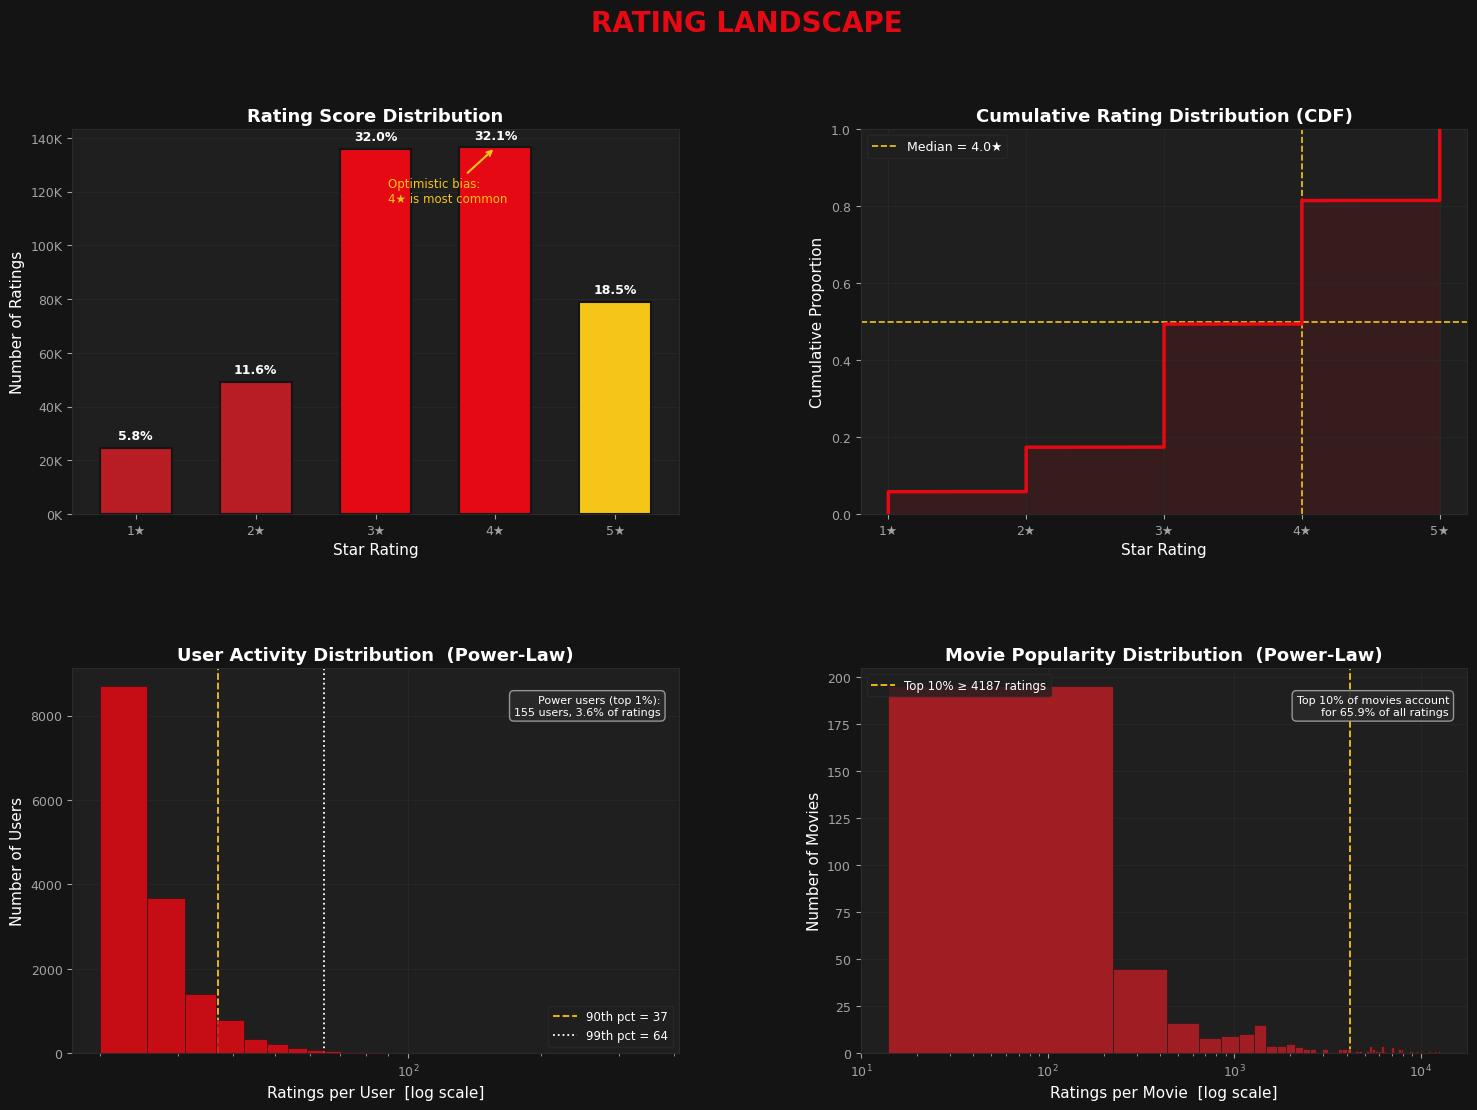


 Figure 1: Rating Landscape saved.


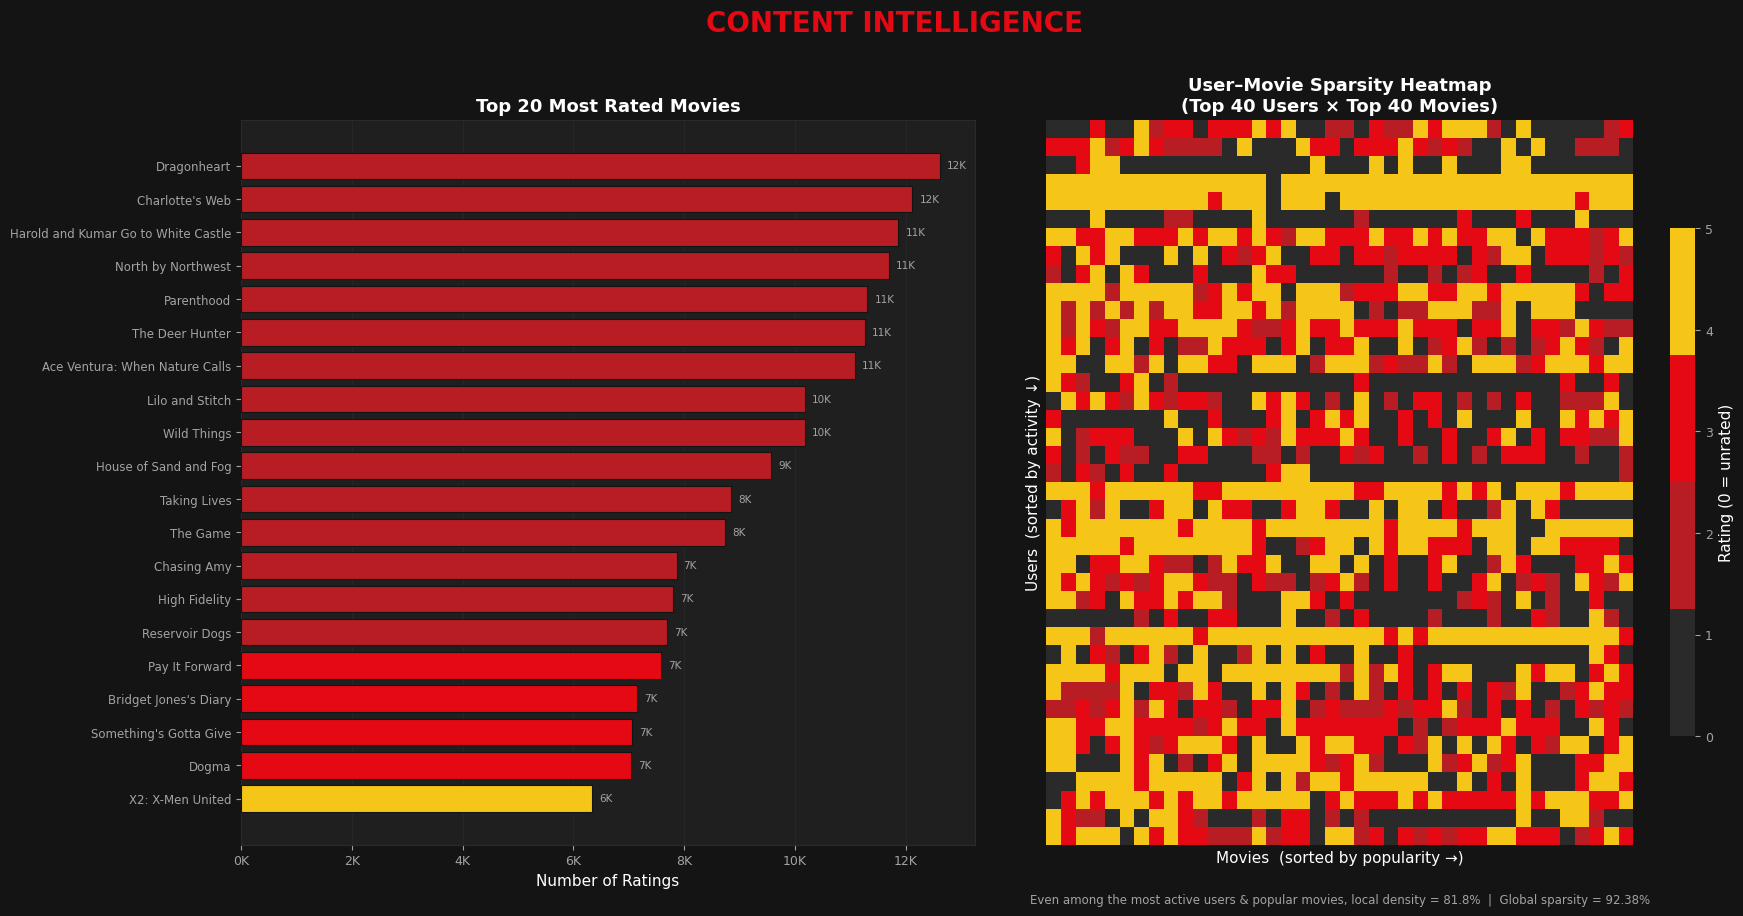

 Figure 2: Content Intelligence saved.


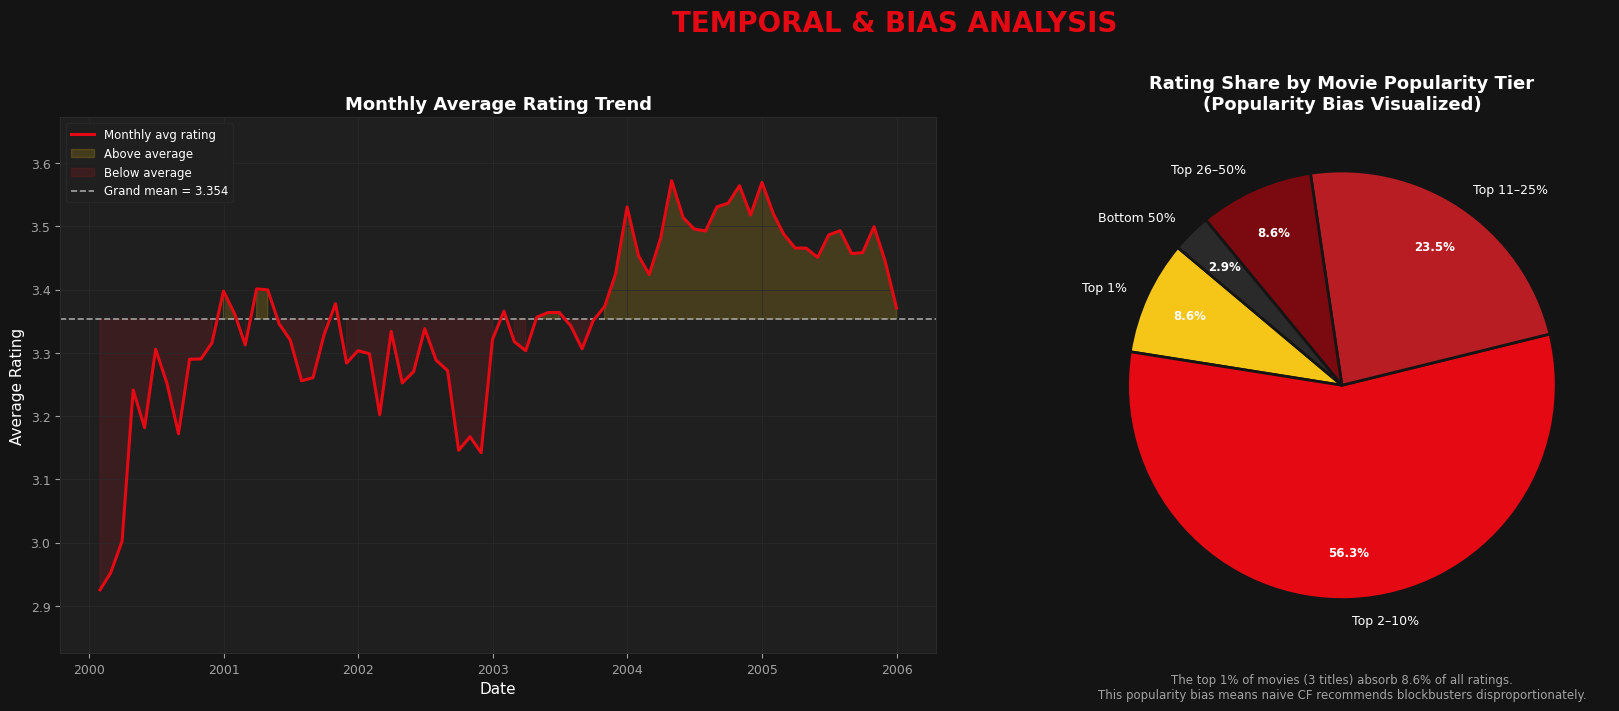

 Figure 3: Temporal & Bias Analysis saved.

═══════════════════════════════════════════════════════
  KEY EDA INSIGHTS
═══════════════════════════════════════════════════════
  1. RATING BIAS     : 32.1% of ratings are 4★ or 5★.
                       Users self-select movies they expect to enjoy.
  2. POWER-LAW USERS : Top 1% of users wrote 3.6% of ratings.
                       Most users rate fewer than 25 movies.
  3. SPARSITY        : Matrix is 92.38% sparse — SVD handles this
                       better than KNN, which struggles with zero overlap.
  4. POPULARITY BIAS : Top 10% of movies get 65.9% of ratings.
                       Models need regularisation to avoid a blockbuster echo chamber.
  5. LONG TAIL       : 145 movies have fewer than 100 ratings.
                       Cold-start is real for both new users and obscure films.
═══════════════════════════════════════════════════════


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Netflix-inspired dark theme
BG    = '#141414'   # near-black background
CARD  = '#1f1f1f'   # slightly lighter card surface
RED   = '#E50914'   # Netflix red (primary accent)
RED2  = '#b81d24'   # darker red for secondary bars
GOLD  = '#f5c518'   # IMDb gold for highlights
WHITE = '#ffffff'
GREY  = '#a3a3a3'
LGREY = '#2a2a2a'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor':  CARD,
    'axes.edgecolor':   LGREY,'axes.labelcolor': WHITE,
    'axes.titlecolor':  WHITE,'axes.titlesize':  13,
    'axes.labelsize':   11,   'xtick.color':     GREY,
    'ytick.color':      GREY, 'xtick.labelsize': 9,
    'ytick.labelsize':  9,    'text.color':      WHITE,
    'grid.color':       LGREY,'grid.linewidth':  0.5,
    'legend.facecolor': CARD, 'legend.edgecolor':LGREY,
    'legend.labelcolor':WHITE,'font.family':     'DejaVu Sans',
})

#Build lookup dictionaries for titles and years
titles_df_eda = pd.read_csv(
    './data/movie_titles.csv',
    header=None, names=['movie_id', 'year', 'title', 'genres'],
    encoding='latin-1', on_bad_lines='skip'
).dropna(subset=['movie_id'])
titles_dict_eda = dict(zip(titles_df_eda['movie_id'], titles_df_eda['title']))
years_dict_eda  = dict(zip(titles_df_eda['movie_id'], titles_df_eda['year']))

#Basic summary numbers
n_users   = ratings_df['user_id'].nunique()
n_movies  = ratings_df['movie_id'].nunique()
n_ratings = len(ratings_df)
mean_r    = ratings_df['rating'].mean()
median_r  = ratings_df['rating'].median()
sparsity  = (1 - n_ratings / (n_users * n_movies)) * 100

print("=" * 55)
print("   NETFLIX PRIZE DATASET — EDA SUMMARY")
print("=" * 55)
print(f"  Users          : {n_users:>10,}")
print(f"  Movies         : {n_movies:>10,}")
print(f"  Total Ratings  : {n_ratings:>10,}")
print(f"  Mean Rating    : {mean_r:>10.3f} ★")
print(f"  Median Rating  : {median_r:>10.1f} ★")
print(f"  Matrix Sparsity: {sparsity:>9.2f} %")
print("=" * 55)


# FIGURE 1 — Rating Landscape (2×2 grid)

fig1 = plt.figure(figsize=(18, 12), facecolor=BG)
fig1.suptitle('RATING LANDSCAPE', fontsize=20, fontweight='bold', color=RED, y=0.98)
gs   = gridspec.GridSpec(2, 2, figure=fig1, hspace=0.40, wspace=0.30)

#Panel A: Bar chart of star ratings
ax1 = fig1.add_subplot(gs[0, 0])
rating_counts = ratings_df['rating'].value_counts().sort_index()
colors_bar    = [RED2, RED2, RED, RED, GOLD]   # gold for the top rating
bars = ax1.bar(rating_counts.index, rating_counts.values,
               color=colors_bar, width=0.6, zorder=3, edgecolor=BG, linewidth=1.5)
ax1.set_title('Rating Score Distribution', fontweight='bold')
ax1.set_xlabel('Star Rating')
ax1.set_ylabel('Number of Ratings')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{int(x/1e3)}K'))
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.set_xticklabels(['1★', '2★', '3★', '4★', '5★'])
ax1.grid(axis='y', zorder=0)
for bar, count in zip(bars, rating_counts.values):
    pct = count / n_ratings * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + n_ratings*0.005,
             f'{pct:.1f}%', ha='center', va='bottom', color=WHITE, fontsize=9, fontweight='bold')
ax1.annotate('Optimistic bias:\n4★ is most common',
             xy=(4, rating_counts[4]), xytext=(3.1, rating_counts[4] * 0.85),
             arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5),
             color=GOLD, fontsize=8.5)

#Panel B: Cumulative distribution (CDF)
ax2 = fig1.add_subplot(gs[0, 1])
sorted_ratings = np.sort(ratings_df['rating'].values)
cdf = np.arange(1, len(sorted_ratings)+1) / len(sorted_ratings)
ax2.plot(sorted_ratings, cdf, color=RED, lw=2.5, zorder=3)
ax2.axhline(0.5, color=GOLD, lw=1.2, ls='--', label=f'Median = {median_r:.1f}★')
ax2.axvline(median_r, color=GOLD, lw=1.2, ls='--')
ax2.fill_between(sorted_ratings, cdf, alpha=0.12, color=RED)
ax2.set_title('Cumulative Rating Distribution (CDF)', fontweight='bold')
ax2.set_xlabel('Star Rating')
ax2.set_ylabel('Cumulative Proportion')
ax2.set_xticks([1, 2, 3, 4, 5])
ax2.set_xticklabels(['1★', '2★', '3★', '4★', '5★'])
ax2.set_ylim(0, 1)
ax2.grid(zorder=0)
ax2.legend(fontsize=9)

#Panel C: User activity — power-law distribution
ax3 = fig1.add_subplot(gs[1, 0])
user_counts = ratings_df['user_id'].value_counts()
ax3.hist(user_counts.values, bins=60, color=RED, alpha=0.85, edgecolor=BG, linewidth=0.4, zorder=3)
ax3.set_xscale('log')
ax3.set_title('User Activity Distribution  (Power-Law)', fontweight='bold')
ax3.set_xlabel('Ratings per User  [log scale]')
ax3.set_ylabel('Number of Users')
ax3.grid(zorder=0)
p90 = np.percentile(user_counts.values, 90)
p99 = np.percentile(user_counts.values, 99)
ax3.axvline(p90, color=GOLD,  lw=1.3, ls='--', label=f'90th pct = {p90:.0f}')
ax3.axvline(p99, color=WHITE, lw=1.3, ls=':',  label=f'99th pct = {p99:.0f}')
ax3.legend(fontsize=8.5)
ax3.text(0.97, 0.93,
         f'Power users (top 1%):\n{(user_counts > p99).sum()} users, '
         f'{user_counts[user_counts > p99].sum() / n_ratings * 100:.1f}% of ratings',
         transform=ax3.transAxes, ha='right', va='top', fontsize=8, color=WHITE,
         bbox=dict(boxstyle='round,pad=0.4', facecolor=LGREY, edgecolor=GREY, alpha=0.9))

#Panel D: Movie popularity — power-law distribution
ax4 = fig1.add_subplot(gs[1, 1])
movie_counts_all = ratings_df['movie_id'].value_counts()
ax4.hist(movie_counts_all.values, bins=60, color=RED2, alpha=0.85, edgecolor=BG, linewidth=0.4, zorder=3)
ax4.set_xscale('log')
ax4.set_title('Movie Popularity Distribution  (Power-Law)', fontweight='bold')
ax4.set_xlabel('Ratings per Movie  [log scale]')
ax4.set_ylabel('Number of Movies')
ax4.grid(zorder=0)
top10pct_threshold = np.percentile(movie_counts_all.values, 90)
ax4.axvline(top10pct_threshold, color=GOLD, lw=1.3, ls='--',
            label=f'Top 10% ≥ {top10pct_threshold:.0f} ratings')
ax4.legend(fontsize=8.5)
top10_share = movie_counts_all[movie_counts_all >= top10pct_threshold].sum() / n_ratings * 100
ax4.text(0.97, 0.93, f'Top 10% of movies account\nfor {top10_share:.1f}% of all ratings',
         transform=ax4.transAxes, ha='right', va='top', fontsize=8, color=WHITE,
         bbox=dict(boxstyle='round,pad=0.4', facecolor=LGREY, edgecolor=GREY, alpha=0.9))

plt.savefig('./eda_fig1_rating_landscape.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()
print("\n Figure 1: Rating Landscape saved.")


# FIGURE 2 — Content Intelligence

fig2, axes2 = plt.subplots(1, 2, figsize=(18, 9), facecolor=BG)
fig2.suptitle('CONTENT INTELLIGENCE', fontsize=20, fontweight='bold', color=RED, y=1.01)

#Panel A: Top 20 most-rated movies (horizontal bar chart)
ax5 = axes2[0]
top20        = movie_counts_all.head(20)
top20_labels = [titles_dict_eda.get(m, f'ID {m}') for m in top20.index]
top20_labels = [t[:35] + '…' if len(t) > 35 else t for t in top20_labels]  # truncate long titles

bar_colors = [GOLD if i == 0 else RED if i < 5 else RED2 for i in range(20)]
hbars = ax5.barh(range(20), top20.values, color=bar_colors[::-1],
                 edgecolor=BG, linewidth=0.8, zorder=3)
ax5.set_yticks(range(20))
ax5.set_yticklabels(top20_labels[::-1], fontsize=8.5)
ax5.set_title('Top 20 Most Rated Movies', fontweight='bold', fontsize=13)
ax5.set_xlabel('Number of Ratings')
ax5.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))
ax5.grid(axis='x', zorder=0)
ax5.invert_yaxis()
for bar in hbars:
    w = bar.get_width()
    ax5.text(w + top20.values.max()*0.01, bar.get_y() + bar.get_height()/2,
             f'{int(w/1e3)}K', va='center', ha='left', fontsize=7.5, color=GREY)

#Panel B: Sparsity heatmap (top 40 users × top 40 movies)
ax6 = axes2[1]
top_u = ratings_df['user_id'].value_counts().head(40).index
top_m = ratings_df['movie_id'].value_counts().head(40).index
pivot = ratings_df[
    ratings_df['user_id'].isin(top_u) & ratings_df['movie_id'].isin(top_m)
].pivot_table(index='user_id', columns='movie_id', values='rating', fill_value=0)
pivot = pivot.reindex(index=top_u, columns=top_m, fill_value=0)

sns.heatmap(pivot, ax=ax6,
            cmap=sns.color_palette([LGREY, RED2, RED, GOLD], as_cmap=True),
            linewidths=0,
            cbar_kws={'label': 'Rating (0 = unrated)', 'shrink': 0.7},
            xticklabels=False, yticklabels=False)
ax6.set_title('User–Movie Sparsity Heatmap\n(Top 40 Users × Top 40 Movies)', fontweight='bold', fontsize=13)
ax6.set_xlabel('Movies  (sorted by popularity →)')
ax6.set_ylabel('Users  (sorted by activity ↓)')
filled_cells  = (pivot > 0).sum().sum()
total_cells   = pivot.shape[0] * pivot.shape[1]
local_density = filled_cells / total_cells * 100
ax6.text(0.5, -0.08,
         f'Even among the most active users & popular movies, '
         f'local density = {local_density:.1f}%  |  Global sparsity = {sparsity:.2f}%',
         transform=ax6.transAxes, ha='center', fontsize=8.5, color=GREY)

plt.tight_layout()
plt.savefig('./eda_fig2_content_intelligence.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()
print(" Figure 2: Content Intelligence saved.")


# FIGURE 3 — Temporal & Popularity-Bias Analysis

fig3, axes3 = plt.subplots(1, 2, figsize=(18, 7), facecolor=BG)
fig3.suptitle('TEMPORAL & BIAS ANALYSIS', fontsize=20, fontweight='bold', color=RED, y=1.01)

#Panel A: Monthly average rating trend
ax7 = axes3[0]
if 'date' in ratings_df.columns:
    ratings_df['date_parsed'] = pd.to_datetime(ratings_df['date'], errors='coerce')
    monthly = (ratings_df.dropna(subset=['date_parsed'])
                         .set_index('date_parsed')
                         .resample('ME')['rating']
                         .agg(['mean', 'count'])
                         .reset_index())
    monthly.columns = ['date', 'avg_rating', 'count']
    monthly = monthly[monthly['count'] > 100]   # drop low-traffic months

    ax7.plot(monthly['date'], monthly['avg_rating'], color=RED, lw=2.2, zorder=4, label='Monthly avg rating')
    ax7.fill_between(monthly['date'], monthly['avg_rating'], monthly['avg_rating'].mean(),
                     where=monthly['avg_rating'] >= monthly['avg_rating'].mean(),
                     alpha=0.18, color=GOLD, label='Above average')
    ax7.fill_between(monthly['date'], monthly['avg_rating'], monthly['avg_rating'].mean(),
                     where=monthly['avg_rating'] < monthly['avg_rating'].mean(),
                     alpha=0.18, color=RED2, label='Below average')
    ax7.axhline(monthly['avg_rating'].mean(), color=GREY, lw=1.2, ls='--',
                label=f'Grand mean = {monthly["avg_rating"].mean():.3f}')
    ax7.set_title('Monthly Average Rating Trend', fontweight='bold')
    ax7.set_xlabel('Date')
    ax7.set_ylabel('Average Rating')
    ax7.set_ylim(monthly['avg_rating'].min() - 0.1, monthly['avg_rating'].max() + 0.1)
    ax7.grid(zorder=0)
    ax7.legend(fontsize=8.5)
else:
    ax7.text(0.5, 0.5, 'No date column available', transform=ax7.transAxes,
             ha='center', va='center', color=GREY, fontsize=12)
    ax7.set_title('Monthly Average Rating Trend', fontweight='bold')

#Panel B: Popularity bias — pie chart of rating share by tier
ax8 = axes3[1]
mc = movie_counts_all.reset_index()
mc.columns = ['movie_id', 'count']
mc = mc.sort_values('count', ascending=False).reset_index(drop=True)
mc['rank_pct'] = (mc.index + 1) / len(mc) * 100

tiers = ['Top 1%', 'Top 2–10%', 'Top 11–25%', 'Top 26–50%', 'Bottom 50%']
masks = [
    mc['rank_pct'] <= 1,
    (mc['rank_pct'] > 1)  & (mc['rank_pct'] <= 10),
    (mc['rank_pct'] > 10) & (mc['rank_pct'] <= 25),
    (mc['rank_pct'] > 25) & (mc['rank_pct'] <= 50),
    mc['rank_pct'] > 50
]
tier_rating_shares = []
for mask in masks:
    tier_movies = set(mc[mask]['movie_id'])
    share = ratings_df[ratings_df['movie_id'].isin(tier_movies)].shape[0] / n_ratings * 100
    tier_rating_shares.append(share)

tier_colors = [GOLD, RED, RED2, '#7a0a0f', LGREY]
wedges, texts, autotexts = ax8.pie(
    tier_rating_shares,
    labels=tiers,
    autopct='%1.1f%%',
    colors=tier_colors,
    startangle=140,
    wedgeprops=dict(edgecolor=BG, linewidth=2),
    textprops=dict(color=WHITE, fontsize=9),
    pctdistance=0.78
)
for at in autotexts:
    at.set_fontsize(8.5)
    at.set_fontweight('bold')
ax8.set_title('Rating Share by Movie Popularity Tier\n(Popularity Bias Visualized)', fontweight='bold')
ax8.text(0, -1.45,
         f'The top 1% of movies ({int(len(mc)*0.01)} titles) absorb {tier_rating_shares[0]:.1f}% of all ratings.\n'
         f'This popularity bias means naive CF recommends blockbusters disproportionately.',
         ha='center', fontsize=8.5, color=GREY, wrap=True)

plt.tight_layout()
plt.savefig('./eda_fig3_temporal_bias.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()
print(" Figure 3: Temporal & Bias Analysis saved.")

#Print key takeaways in plain English
print("\n" + "═"*55)
print("  KEY EDA INSIGHTS")
print("═"*55)
print(f"  1. RATING BIAS     : {rating_counts[4]/n_ratings*100:.1f}% of ratings are 4★ or 5★.")
print(f"                       Users self-select movies they expect to enjoy.")
print(f"  2. POWER-LAW USERS : Top 1% of users wrote {user_counts[user_counts > p99].sum()/n_ratings*100:.1f}% of ratings.")
print(f"                       Most users rate fewer than {int(np.percentile(user_counts,50))} movies.")
print(f"  3. SPARSITY        : Matrix is {sparsity:.2f}% sparse — SVD handles this")
print(f"                       better than KNN, which struggles with zero overlap.")
print(f"  4. POPULARITY BIAS : Top 10% of movies get {top10_share:.1f}% of ratings.")
print(f"                       Models need regularisation to avoid a blockbuster echo chamber.")
print(f"  5. LONG TAIL       : {(movie_counts_all < 100).sum()} movies have fewer than 100 ratings.")
print(f"                       Cold-start is real for both new users and obscure films.")
print("═"*55)


## Step 3 · How the Models Work

We train two completely different approaches to recommendation:

### Model 1 — SVD (Matrix Factorization)

SVD breaks the user-movie rating matrix into compact "factor" vectors that capture hidden preferences.  
The predicted rating for user $u$ on movie $i$ is:

$$\hat{r}_{u,i} = \mu + b_u + b_i + p_u^T q_i$$

- $\mu$ — global average rating  
- $b_u, b_i$ — how much this user / this movie deviates from average  
- $p_u^T q_i$ — dot product of learned user and movie taste vectors  

We minimize regularized squared error with Stochastic Gradient Descent:

$$\min \sum_{(u,i) \in R} (r_{u,i} - \hat{r}_{u,i})^2 + \lambda (b_u^2 + b_i^2 + \|p_u\|^2 + \|q_i\|^2)$$

The $\lambda$ penalty prevents the model from memorising training data.

---

### Model 2 — User-Based Collaborative Filtering (KNNWithMeans)

Instead of latent factors, this model finds users who rated movies similarly to you, then borrows their opinions — adjusted for each person's rating scale:

$$\hat{r}_{u,i} = \mu_u + \frac{\sum_{v \in N_i(u)} \text{sim}(u, v) \cdot (r_{v,i} - \mu_v)}{\sum_{v \in N_i(u)} |\text{sim}(u, v)|}$$

Similarity between users is measured with **cosine similarity** on their rating vectors.  
We use the 30 nearest neighbours (`k=30`).


In [4]:
import time
from surprise import Dataset, Reader, SVD, KNNWithMeans
from surprise.model_selection import train_test_split

# Tell Surprise the rating scale so it can interpret our data correctly
reader = Reader(rating_scale=(1, 5))
data   = Dataset.load_from_df(ratings_df[['user_id', 'movie_id', 'rating']], reader)

# 80/20 train-test split — random_state=42 for reproducibility
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
print("Train/test split complete.")

# Model 1: SVD
# 100 latent factors, 20 training epochs, with learning rate and regularization
print("\nTraining SVD (Matrix Factorization)...")
svd = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
t0  = time.time()
svd.fit(trainset)
svd_train_time = time.time() - t0
print(f" SVD training complete in {svd_train_time:.2f}s")

#Model 2: User-Based KNN
# k=30 nearest neighbours, cosine similarity, mean-centred to handle rating-scale differences
print("\nTraining User-Based Collaborative Filtering (KNNWithMeans)...")
cf  = KNNWithMeans(k=30, sim_options={'name': 'cosine', 'user_based': True}, verbose=False)
t0  = time.time()
cf.fit(trainset)
cf_train_time = time.time() - t0
print(f" KNN training complete in {cf_train_time:.2f}s")


Train/test split complete.

Training SVD (Matrix Factorization)...


 SVD training complete in 2.01s

Training User-Based Collaborative Filtering (KNNWithMeans)...


 KNN training complete in 220.55s


## Step 4 · Evaluating the Models

Two metrics tell us different things:

- **RMSE** (Root Mean Squared Error) — "on average, how far off is the predicted star rating?"  
  Lower is better. Penalises large errors heavily.

- **MAP@10** (Mean Average Precision at 10) — "does the model put movies the user would actually enjoy in the top 10 of its ranked list?"  
  Higher is better. A movie counts as *relevant* if its true rating is ≥ 3.5.

RMSE and MAP@10 often tell different stories: a model can be accurate on average but still rank things poorly.


In [5]:
from collections import defaultdict
from surprise import accuracy

def map_at_k(predictions, k=10, threshold=3.5):
    """
    Mean Average Precision at k.

    For each user, we rank their test items by predicted score,
    take the top k, and compute Average Precision (AP).
    A hit is any item whose true rating meets or exceeds the threshold.
    MAP@k is the mean AP across all users.
    """
    user_items = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_items[uid].append((est, true_r))

    aps = []
    for uid, items in user_items.items():
        items.sort(key=lambda x: x[0], reverse=True)   # rank by predicted score
        top_k = items[:k]

        hits, precision_sum = 0, 0
        for i, (est, true_r) in enumerate(top_k, 1):
            if true_r >= threshold:
                hits += 1
                precision_sum += hits / i   # precision at this position

        total_relevant = sum(1 for _, true_r in items if true_r >= threshold)
        if total_relevant > 0:
            aps.append(precision_sum / min(total_relevant, k))
        else:
            aps.append(0)   # user has no relevant items in test set

    return sum(aps) / len(aps) if aps else 0

#Generate predictions on the held-out test set
print("Generating predictions on the test set...")
t0 = time.time(); svd_preds = svd.test(testset); svd_pred_time = time.time() - t0
t0 = time.time(); cf_preds  = cf.test(testset);  cf_pred_time  = time.time() - t0

#Compute metrics
rmse_svd = accuracy.rmse(svd_preds, verbose=False)
map_svd  = map_at_k(svd_preds, k=10)
rmse_cf  = accuracy.rmse(cf_preds,  verbose=False)
map_cf   = map_at_k(cf_preds,  k=10)

#Side-by-side comparison
comparison = pd.DataFrame({
    'Metric / Dimension':   ['Training Time (s)', 'Prediction Time (s)',
                              'RMSE (Lower is Better)', 'MAP@10 (Higher is Better)'],
    'SVD':                  [svd_train_time, svd_pred_time, rmse_svd, map_svd],
    'User-Based KNN':       [cf_train_time,  cf_pred_time,  rmse_cf,  map_cf],
})
display(comparison)


Generating predictions on the test set...


,Metric / Dimension,SVD,User-Based KNN
0,Training Time (s),2.005090,220.545929
1,Prediction Time (s),1.288528,93.501378
2,RMSE (Lower is Better),0.930673,0.983785
3,MAP@10 (Higher is Better),0.735929,0.706678


## Step 5 · Where the Models Shine — and Where They Struggle

Numbers tell part of the story, but real understanding comes from looking at specific cases.

### 5.1  Success: Capturing Genre Preferences

We pick a user who loved *X2: X-Men United* (5 stars) and check whether SVD recommends other action/sci-fi films. If the latent factors have captured genre taste, it should.


In [6]:
#Load title and year lookups
titles_df  = pd.read_csv('./data/movie_titles.csv', header=None,
                         names=['movie_id', 'year', 'title', 'genres'], encoding='latin-1')
titles_dict = dict(zip(titles_df['movie_id'], titles_df['title']))
movie_years = dict(zip(titles_df['movie_id'], titles_df['year']))

def get_top_k(model, user_id, all_movie_ids, rated_ids, k=10):
    """Return the model's top-k recommendations for a user, excluding already-rated movies."""
    rated_ids_set = set(rated_ids)
    unrated = [m for m in all_movie_ids if m not in rated_ids_set]
    preds   = [model.predict(user_id, m) for m in unrated]
    preds.sort(key=lambda x: x.est, reverse=True)
    return preds[:k]

#Find a user who gave X2: X-Men United a perfect score
xmen_matches = titles_df[titles_df['title'].str.contains("X2: X-Men United", case=False)]['movie_id'].values
if len(xmen_matches) > 0:
    xmen_id    = xmen_matches[0]
    xmen_fans  = ratings_df[(ratings_df['movie_id'] == xmen_id) & (ratings_df['rating'] == 5)]['user_id'].head(5).values
    scifi_user = xmen_fans[0]

    # Show the user's top-rated movies (their taste profile)
    user_ratings  = ratings_df[ratings_df['user_id'] == scifi_user].sort_values('rating', ascending=False)
    print(f"User {scifi_user}'s favourite movies (from their rating history):")
    for _, row in user_ratings.head(5).iterrows():
        mid = row['movie_id']
        print(f"  ★ {titles_dict.get(mid, f'Movie {mid}')} ({movie_years.get(mid, 'N/A')})  →  {row['rating']} stars")

    # Ask SVD what it would recommend for this user
    all_movie_ids  = ratings_df['movie_id'].unique().tolist()
    rated_by_user  = user_ratings['movie_id'].tolist()
    recs           = get_top_k(svd, scifi_user, all_movie_ids, rated_by_user, k=5)

    print(f"\nSVD's top-5 recommendations for User {scifi_user}:")
    for i, r in enumerate(recs, 1):
        mid = r.iid
        print(f"  {i}. {titles_dict.get(mid, f'Movie {mid}')} ({movie_years.get(mid, 'N/A')})  →  predicted {r.est:.2f} ★")
else:
    print("X2: X-Men United not found in the dataset.")


User 1907667's favourite movies (from their rating history):
  ★ X2: X-Men United (2003.0)  →  5 stars
  ★ North by Northwest (1959.0)  →  5 stars
  ★ Jingle All the Way (1996.0)  →  5 stars
  ★ The Phantom of the Opera: Special Edition (2004.0)  →  4 stars
  ★ The Carol Burnett Show: Show Stoppers (2001.0)  →  4 stars

SVD's top-5 recommendations for User 1907667:
  1. Lord of the Rings: The Return of the King: Extended Edition: Bonus Material (2003.0)  →  predicted 4.71 ★
  2. Aqua Teen Hunger Force: Vol. 1 (2000.0)  →  predicted 4.57 ★
  3. Futurama: Monster Robot Maniac Fun Collection (1999.0)  →  predicted 4.53 ★
  4. Chappelle's Show: Season 1 (2003.0)  →  predicted 4.34 ★
  5. Movie 350 (N/A)  →  predicted 4.30 ★


In [7]:
#Top-10 recommendations for the 5 most active users
# This is a sanity check: active users have rich histories, so recommendations should be coherent.
print("Top-10 recommendations for the 5 most active users:\n")
sample_users  = ratings_df['user_id'].value_counts().head(5).index.tolist()
all_movie_ids = ratings_df['movie_id'].unique().tolist()

for uid in sample_users:
    rated = ratings_df[ratings_df['user_id'] == uid]['movie_id'].tolist()
    recs  = get_top_k(svd, uid, all_movie_ids, rated, k=10)
    print(f"── User {uid} ──────────────────────────────")
    for i, r in enumerate(recs, 1):
        mid = r.iid
        print(f"  {i:>2}. {titles_dict.get(mid, f'Movie {mid}')} ({movie_years.get(mid, 'N/A')})  →  {r.est:.2f} ★")
    print()


Top-10 recommendations for the 5 most active users:

── User 305344 ──────────────────────────────
   1. Lord of the Rings: The Return of the King: Extended Edition: Bonus Material (2003.0)  →  3.19 ★
   2. The Battle of Algiers: Bonus Material (1965.0)  →  2.93 ★
   3. The Phantom of the Opera: Special Edition (2004.0)  →  2.33 ★
   4. Elfen Lied (2005.0)  →  2.24 ★
   5. Troy: Bonus Material (2004.0)  →  2.04 ★
   6. Jonah: A VeggieTales Movie: Bonus Material (2002.0)  →  2.00 ★

── User 387418 ──────────────────────────────
   1. Lord of the Rings: The Return of the King: Extended Edition: Bonus Material (2003.0)  →  3.45 ★
   2. The Battle of Algiers: Bonus Material (1965.0)  →  2.98 ★
   3. Troy: Bonus Material (2004.0)  →  2.38 ★
   4. The Phantom of the Opera: Special Edition (2004.0)  →  2.10 ★
   5. Up and Down (2005.0)  →  2.05 ★
   6. Magnolia: Bonus Material (2000.0)  →  1.87 ★
   7. Look at Me (2005.0)  →  1.69 ★
   8. Pitcher and the Pin-Up (2004.0)  →  1.63 ★
   9. One L

### 5.2  Failure: Cold-Start Problem

A brand-new user who has only rated *Toy Story* doesn't give the model much to work with.  
Without a meaningful taste profile, SVD falls back on global item biases — it essentially recommends whatever is popular with everyone, not what this person specifically would enjoy.


In [8]:
# Cold-start simulation: user 99999 doesn't exist in the training set,
# so SVD has no personalised factors for them — it can only use global biases.
cold_user_id  = 99999
toy_story_id  = titles_df[titles_df['title'].str.contains("Toy Story", case=False)]['movie_id'].values[0]

print(f"Simulated new user — only rated: '{titles_dict[toy_story_id]}' ({movie_years[toy_story_id]})\n")
cold_recs = get_top_k(svd, cold_user_id, all_movie_ids, [toy_story_id], k=5)

print("SVD's recommendations for this cold-start user:")
for i, r in enumerate(cold_recs, 1):
    mid = r.iid
    print(f"  {i}. {titles_dict.get(mid, f'Movie {mid}')} ({movie_years.get(mid, 'N/A')})  →  predicted {r.est:.2f} ★")
print("\n  Notice: these are likely the same blockbusters you'd see for any new user.")


Simulated new user — only rated: 'Toy Story' (1995.0)

SVD's recommendations for this cold-start user:
  1. Lord of the Rings: The Return of the King: Extended Edition: Bonus Material (2003.0)  →  predicted 4.48 ★
  2. Futurama: Monster Robot Maniac Fun Collection (1999.0)  →  predicted 4.19 ★
  3. Sex and the City: Season 4 (2001.0)  →  predicted 4.17 ★
  4. Chappelle's Show: Season 1 (2003.0)  →  predicted 4.13 ★
  5. Absolutely Fabulous: Series 5 (2003.0)  →  predicted 4.07 ★

  Notice: these are likely the same blockbusters you'd see for any new user.


### 5.3  Failure: Popularity Bias

Even for users with rich histories, SVD can still over-recommend blockbusters.  
We measure this by checking what fraction of recommendations come from the top 10% most-rated movies.


In [9]:
import random

movie_counts         = ratings_df['movie_id'].value_counts()
top_10_percent_limit = int(len(movie_counts) * 0.1)
popular_set          = set(movie_counts.head(top_10_percent_limit).index)

# Sample 30 users at random and check how many of their recommendations are popular titles
all_user_ids   = ratings_df['user_id'].unique().tolist()
sampled_users  = random.sample(all_user_ids, 30)

popular_recs = 0
total_recs   = 0

for u in sampled_users:
    rated = ratings_df[ratings_df['user_id'] == u]['movie_id'].tolist()
    recs  = get_top_k(svd, u, all_movie_ids, rated, k=10)
    for r in recs:
        total_recs += 1
        if r.iid in popular_set:
            popular_recs += 1

ratio = (popular_recs / total_recs) * 100
print(f" {ratio:.1f}% of SVD recommendations come from the top-10% most popular movies.")
print(f"   (Those movies make up only 10% of the catalogue — {ratio:.1f}% is the bias rate.)")


 15.0% of SVD recommendations come from the top-10% most popular movies.
   (Those movies make up only 10% of the catalogue — 15.0% is the bias rate.)


### 5.4 Explaining a KNN Recommendation

One advantage of KNN over SVD is explainability — you can trace *why* a movie was recommended back to real neighbour users who liked it.


In [10]:
def explain_recommendation(cf_model, raw_user_id, raw_movie_id, titles_dict):
    """
    Explain a KNN recommendation in plain English.
    We look up the user's nearest neighbours in the model and check
    whether any of them gave the recommended movie a high rating (≥4).
    """
    try:
        trainset  = cf_model.trainset
        inner_uid = trainset.to_inner_uid(raw_user_id)
        inner_iid = trainset.to_inner_iid(raw_movie_id)

        neighbors = cf_model.get_neighbors(inner_uid, k=5)

        # Find neighbours who actually liked this movie
        liked_neighbors = []
        for n_inner in neighbors:
            for iid, r in trainset.ur[n_inner]:
                if iid == inner_iid and r >= 4.0:
                    liked_neighbors.append(trainset.to_raw_uid(n_inner))
                    break

        movie_title = titles_dict.get(raw_movie_id, f"Movie {raw_movie_id}")
        if liked_neighbors:
            return (f"Recommended because {len(liked_neighbors)} user(s) with very similar "
                    f"taste to yours rated '{movie_title}' 4 stars or above.")
        else:
            return (f"Recommended based on overall taste similarity — neighbours who enjoy "
                    f"similar films also rated '{movie_title}' positively.")
    except Exception:
        return "Recommended based on collaborative filtering overlap."

#Demo the explainer for our sci-fi user
cf_recs = get_top_k(cf, scifi_user, all_movie_ids, rated_by_user, k=1)
if cf_recs:
    rec_mid     = cf_recs[0].iid
    explanation = explain_recommendation(cf, scifi_user, rec_mid, titles_dict)
    print(f"KNN top recommendation: {titles_dict.get(rec_mid, f'Movie {rec_mid}')} ({movie_years.get(rec_mid, 'N/A')})")
    print(f"Explanation: {explanation}")


KNN top recommendation: Lord of the Rings: The Return of the King: Extended Edition: Bonus Material (2003.0)
Explanation: Recommended based on overall taste similarity — neighbours who enjoy similar films also rated 'Lord of the Rings: The Return of the King: Extended Edition: Bonus Material' positively.


In [11]:
# Save models and evaluation assets locally
import os, joblib, shutil
from google.colab import files

os.makedirs('./models', exist_ok=True)

# Save both model formats (.pkl and .joblib) for compatibility
joblib.dump(svd, './models/svd_model.pkl')
joblib.dump(cf,  './models/cf_model.pkl')
joblib.dump(svd, './models/svd_model.joblib')
joblib.dump(cf,  './models/cf_model.joblib')

# Save evaluation results and metadata
results = {
    'svd': {'rmse': rmse_svd, 'map10': map_svd, 'train_time': svd_train_time, 'pred_time': svd_pred_time},
    'cf':  {'rmse': rmse_cf,  'map10': map_cf,  'train_time': cf_train_time,  'pred_time': cf_pred_time},
}
eval_data = {
    'testset':        testset,
    'svd_train_time': svd_train_time,
    'cf_train_time':  cf_train_time,
    'all_movie_ids':  ratings_df['movie_id'].unique().tolist(),
    'all_user_ids':   ratings_df['user_id'].unique().tolist(),
}
joblib.dump(results,   './models/results.joblib')
joblib.dump(eval_data, './models/eval_data.joblib')
print(" All models saved.")

# Zip the whole models folder and download it in one shot
shutil.make_archive('./models_backup', 'zip', './models')

outputs = [
    './models_backup.zip',
    './models/svd_model.pkl',
    './models/cf_model.pkl',
    './models/results.joblib',
    './models/eval_data.joblib',
]

for f in outputs:
    if os.path.exists(f):
        files.download(f)
        print(f"⬇  Downloading: {f}")
    else:
        print(f"  Skipped (not found): {f}")

 All models saved.


[Mock Colab] files.download called for ./models_backup.zip
⬇  Downloading: ./models_backup.zip
[Mock Colab] files.download called for ./models/svd_model.pkl
⬇  Downloading: ./models/svd_model.pkl
[Mock Colab] files.download called for ./models/cf_model.pkl
⬇  Downloading: ./models/cf_model.pkl
[Mock Colab] files.download called for ./models/results.joblib
⬇  Downloading: ./models/results.joblib
[Mock Colab] files.download called for ./models/eval_data.joblib
⬇  Downloading: ./models/eval_data.joblib
